Dataset

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.drop(columns=['id', 'Unnamed: 32'],inplace=True)

In [5]:
df.shape

(569, 31)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [37]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()
print(X_train_tensor.shape, X_test_tensor.shape, y_train_tensor.shape, y_test_tensor.shape)

torch.Size([455, 30]) torch.Size([114, 30]) torch.Size([455]) torch.Size([114])


In [38]:
class Nmodel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )

    def forward(self, features):
        out = self.network(features)
        return out

In [39]:
learning_rate = 0.1
epochs = 25
batch_size = 32
n_samples = len(X_train_tensor)

In [83]:
model = Nmodel(X_train_tensor.shape[1])

loss_function = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
history = []
history_accuracy = []

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0
    total = 0
    for start_idx in range(0, n_samples, batch_size):
        end_idx = start_idx + batch_size
        X_batch = X_train_tensor[start_idx:end_idx]
        y_batch = y_train_tensor[start_idx:end_idx]

        y_pred = model(X_batch)
        
        loss = loss_function(y_pred, y_batch.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        pred = (y_pred >+ 0.5).float()
        correct += (pred == y_batch.view(-1, 1)).sum().item()
        total += y_batch.size(0)

    epoch_loss = epoch_loss / ((n_samples + batch_size - 1) // batch_size)
    history.append(epoch_loss)
    history_accuracy.append(correct/total)
    print(f" Epoch: {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {correct/total:.4f}")

 Epoch: 1, Loss: 0.7276, Accuracy: 0.3582
 Epoch: 2, Loss: 0.6740, Accuracy: 0.5099
 Epoch: 3, Loss: 0.6188, Accuracy: 0.6637
 Epoch: 4, Loss: 0.5673, Accuracy: 0.7582
 Epoch: 5, Loss: 0.5218, Accuracy: 0.8242
 Epoch: 6, Loss: 0.4813, Accuracy: 0.8462
 Epoch: 7, Loss: 0.4452, Accuracy: 0.8703
 Epoch: 8, Loss: 0.4129, Accuracy: 0.8791
 Epoch: 9, Loss: 0.3838, Accuracy: 0.8879
 Epoch: 10, Loss: 0.3578, Accuracy: 0.8967
 Epoch: 11, Loss: 0.3346, Accuracy: 0.9055
 Epoch: 12, Loss: 0.3137, Accuracy: 0.9121
 Epoch: 13, Loss: 0.2951, Accuracy: 0.9121
 Epoch: 14, Loss: 0.2785, Accuracy: 0.9209
 Epoch: 15, Loss: 0.2636, Accuracy: 0.9231
 Epoch: 16, Loss: 0.2499, Accuracy: 0.9231
 Epoch: 17, Loss: 0.2370, Accuracy: 0.9253
 Epoch: 18, Loss: 0.2252, Accuracy: 0.9297
 Epoch: 19, Loss: 0.2145, Accuracy: 0.9319
 Epoch: 20, Loss: 0.2047, Accuracy: 0.9341
 Epoch: 21, Loss: 0.1957, Accuracy: 0.9363
 Epoch: 22, Loss: 0.1874, Accuracy: 0.9407
 Epoch: 23, Loss: 0.1799, Accuracy: 0.9407
 Epoch: 24, Loss: 0.

In [85]:
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)

y_pred = (y_pred_prob >= 0.5).float()

ypred = y_pred.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))


Accuracy: 0.956140350877193
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96        64
         1.0       0.96      0.94      0.95        50

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.96       114
weighted avg       0.96      0.96      0.96       114



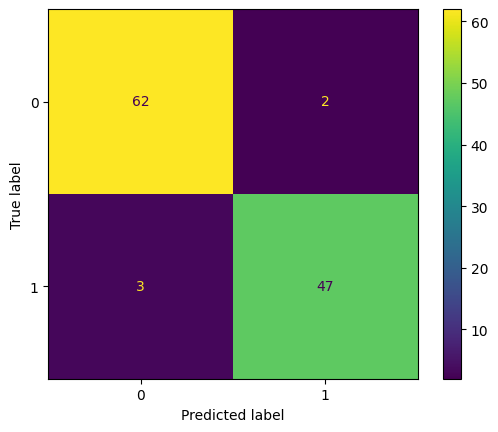

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_np, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

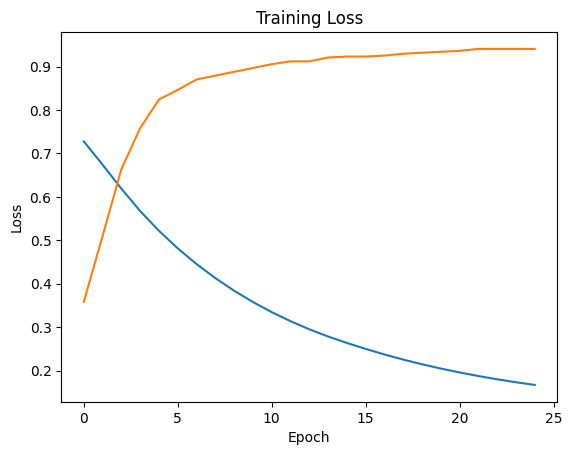

In [87]:
plt.plot(history)
plt.plot(history_accuracy)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()